In [1]:
print("hi")

hi


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
import os
import sys
import findspark

# 1. KHAI BÁO BIẾN MÔI TRƯỜNG TRƯỚC
# Sử dụng Raw string (r'') là đúng, nhưng hãy kiểm tra kỹ dấu gạch chéo
spark_home = r'C:\Program Files\Spark\spark-3.5.8-bin-hadoop3'
java_home = r'C:\Program Files\Java\jdk-11'
hadoop_home = r'C:\Program Files\Winutils'

os.environ['SPARK_HOME'] = spark_home
os.environ['JAVA_HOME'] = java_home
os.environ['HADOOP_HOME'] = hadoop_home

# 2. KHỞI TẠO FINDSPARK (Truyền trực tiếp đường dẫn vào để chắc chắn)
findspark.init(spark_home)

# 3. SAU ĐÓ MỚI IMPORT CÁC THƯ VIỆN CỦA PYSPARK
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

try:
    # 4. KHỞI TẠO SESSION
    # Thêm cấu hình địa chỉ warehouse để tránh lỗi quyền ghi đè trên Windows
    spark = SparkSession.builder \
        .appName("OTTO_Recommendation_EDA") \
        .config("spark.driver.memory", "4g") \
        .config("spark.sql.warehouse.dir", "file:///C:/temp") \
        .getOrCreate()
    
    print("--- Chúc mừng! Spark đã khởi động thành công ---")
    print("Phiên bản Spark Core:", spark.version)
    
    # Test thử
    spark.createDataFrame([("Ngo Bo", "Pass")], ["Student", "Result"]).show()

except Exception as e:
    print("Vẫn còn lỗi. Hãy kiểm tra các mục sau:")
    print(f"Chi tiết lỗi: {e}")

--- Chúc mừng! Spark đã khởi động thành công ---
Phiên bản Spark Core: 3.5.8
+-------+------+
|Student|Result|
+-------+------+
| Ngo Bo|  Pass|
+-------+------+



In [4]:
# Đọc dữ liệu
df = spark.read.json("0.jsonl")

# Phẳng hóa events và trích xuất thông tin
df_flat = df.select(
    F.col("session"),
    F.explode(F.col("events")).alias("event")
).select(
    "session",
    F.col("event.aid").alias("aid"),
    F.col("event.ts").alias("ts"),
    F.col("event.type").alias("type")
)

In [5]:
# Chuyển timestamp sang format dễ đọc
df_flat = df_flat.withColumn("timestamp", F.from_unixtime(F.col("ts") / 1000).cast("timestamp"))
df_flat = df_flat.withColumn("hour", F.hour("timestamp"))
df_flat = df_flat.withColumn("day_of_week", F.dayofweek("timestamp"))

# Cache lại để các cell sau chạy cực nhanh
df_flat.cache()
df_flat.show(5)

+-------+---+-------------+----+-------------------+----+-----------+
|session|aid|           ts|type|          timestamp|hour|day_of_week|
+-------+---+-------------+----+-------------------+----+-----------+
|      0|  0|1659304800025|   0|2022-08-01 05:00:00|   5|          2|
|      0|  1|1659304904511|   0|2022-08-01 05:01:44|   5|          2|
|      0|  2|1659367439426|   0|2022-08-01 22:23:59|  22|          2|
|      0|  3|1659367719997|   0|2022-08-01 22:28:39|  22|          2|
|      0|  4|1659367871344|   0|2022-08-01 22:31:11|  22|          2|
+-------+---+-------------+----+-------------------+----+-----------+
only showing top 5 rows



C:\Users\LAPTOP HP\AppData\Local\Temp\ipykernel_9612\402048163.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=type_counts, x='type_name', y='count', palette='Blues_r')


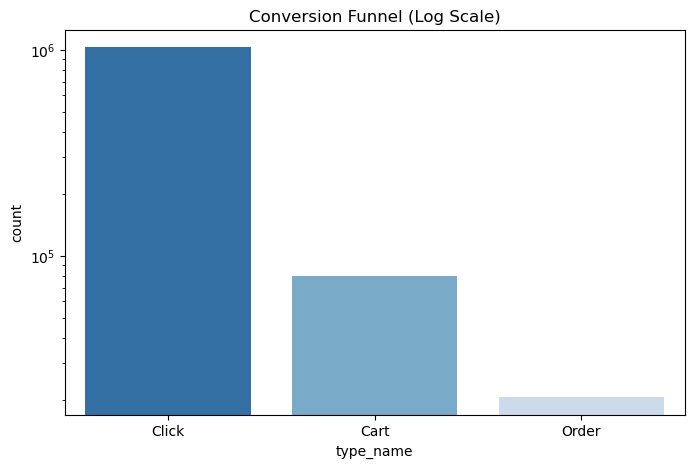

Tỷ lệ Click-to-Order: 2.00%


In [6]:
# Thống kê số lượng theo loại hành động
type_counts = df_flat.groupBy("type").count().toPandas()
type_mapping = {0: 'Click', 1: 'Cart', 2: 'Order'}
type_counts['type_name'] = type_counts['type'].map(type_mapping)

plt.figure(figsize=(8, 5))
sns.barplot(data=type_counts, x='type_name', y='count', palette='Blues_r')
plt.yscale('log')
plt.title('Conversion Funnel (Log Scale)')
plt.show()

# Tính tỷ lệ chuyển đổi
total_clicks = type_counts[type_counts['type']==0]['count'].values[0]
total_orders = type_counts[type_counts['type']==2]['count'].values[0]
print(f"Tỷ lệ Click-to-Order: {(total_orders/total_clicks)*100:.2f}%")

Phân tích Sản phẩm

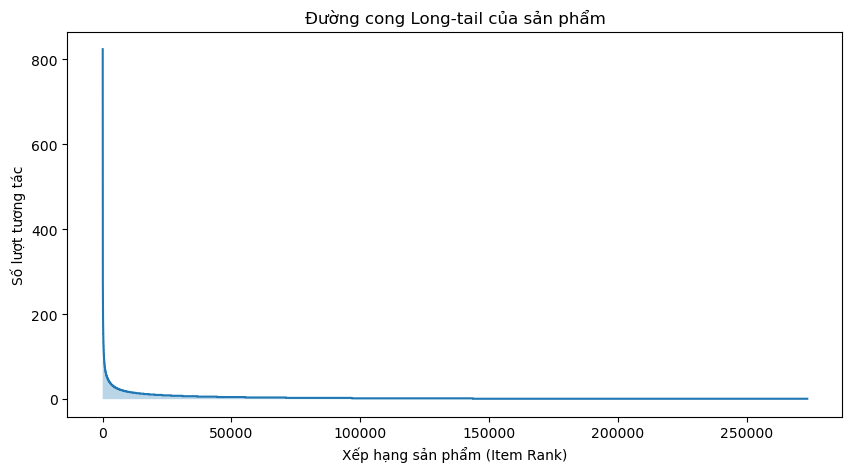

Top 1% sản phẩm chiếm 18.87% tổng tương tác.


In [11]:
item_stats = df_flat.groupBy("aid").count().orderBy(F.desc("count")).toPandas()

plt.figure(figsize=(10, 5))
plt.plot(range(len(item_stats)), item_stats['count'])
plt.fill_between(range(len(item_stats)), item_stats['count'], alpha=0.3)
plt.title('Đường cong Long-tail của sản phẩm')
plt.xlabel('Xếp hạng sản phẩm (Item Rank)')
plt.ylabel('Số lượt tương tác')
plt.show()

print(f"Top 1% sản phẩm chiếm {item_stats.head(int(len(item_stats)*0.01))['count'].sum() / item_stats['count'].sum() * 100:.2f}% tổng tương tác.")

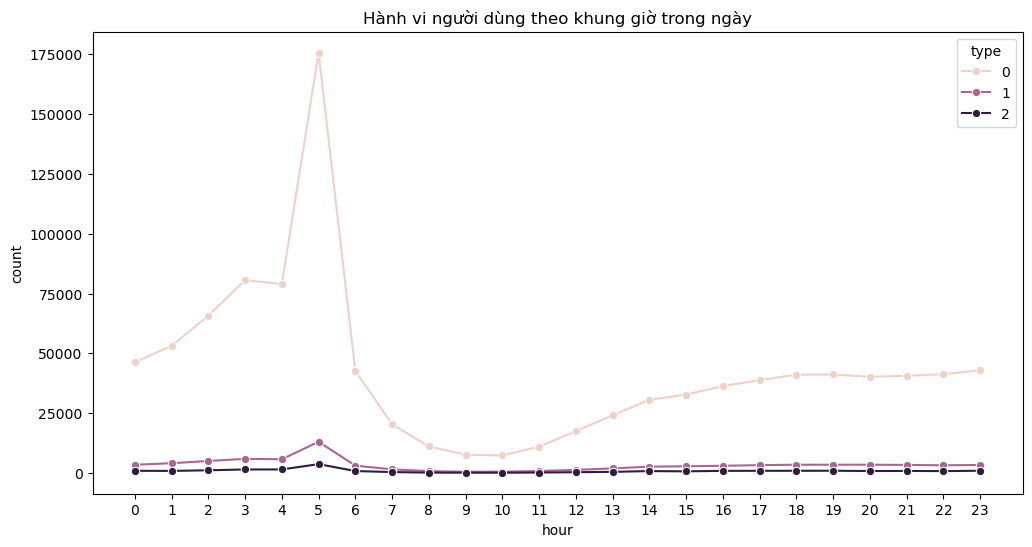

In [13]:
hourly_data = df_flat.groupBy("hour", "type").count().toPandas()

plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_data, x='hour', y='count', hue='type', marker='o')
plt.title('Hành vi người dùng theo khung giờ trong ngày')
plt.xticks(range(0, 24))
plt.show()

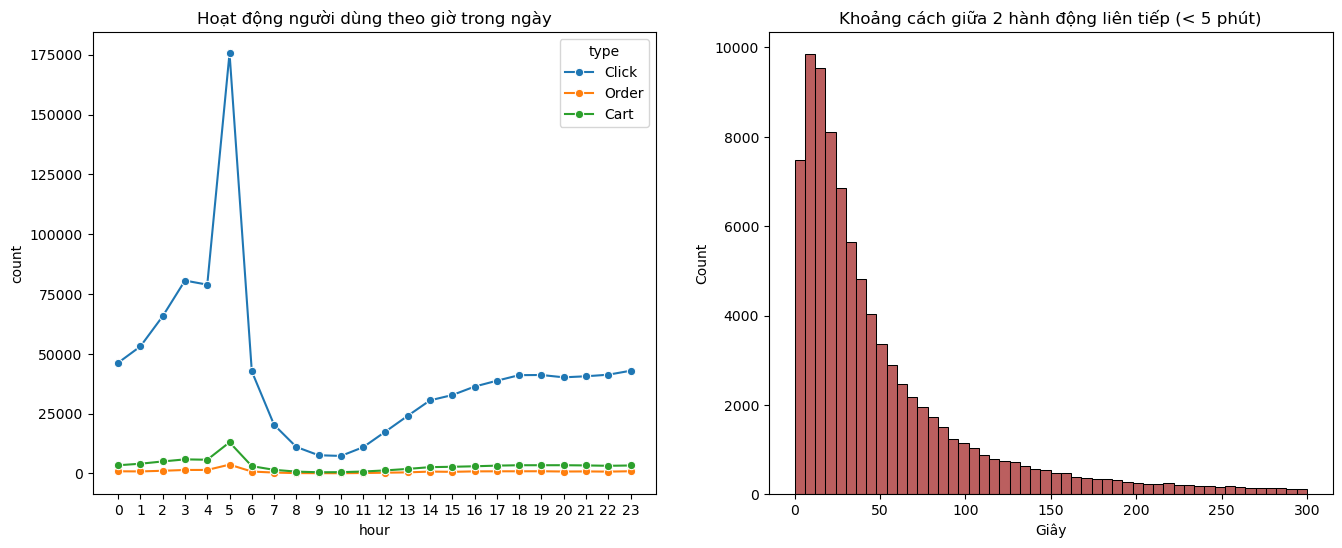

In [14]:
# 1. Hoạt động theo giờ và loại hành động
hourly_activity = df_flat.groupBy("hour", "type").count().toPandas()
hourly_activity['type'] = hourly_activity['type'].map({0: 'Click', 1: 'Cart', 2: 'Order'})

# 2. Inter-arrival time (Khoảng cách giữa các click)
window_spec = Window.partitionBy("session").orderBy("ts")
df_diff = df_flat.withColumn("prev_ts", F.lag("ts").over(window_spec))
df_diff = df_diff.withColumn("diff_sec", (F.col("ts") - F.col("prev_ts")) / 1000)
inter_arrival = df_diff.filter(F.col("diff_sec").isNotNull()).select("diff_sec").sample(0.1).toPandas()

# Vẽ biểu đồ
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.lineplot(data=hourly_activity, x='hour', y='count', hue='type', marker='o', ax=ax[0])
ax[0].set_title("Hoạt động người dùng theo giờ trong ngày")
ax[0].set_xticks(range(0, 24))

sns.histplot(inter_arrival[inter_arrival['diff_sec'] < 300]['diff_sec'], bins=50, ax=ax[1], color='brown')
ax[1].set_title("Khoảng cách giữa 2 hành động liên tiếp (< 5 phút)")
ax[1].set_xlabel("Giây")

plt.show()

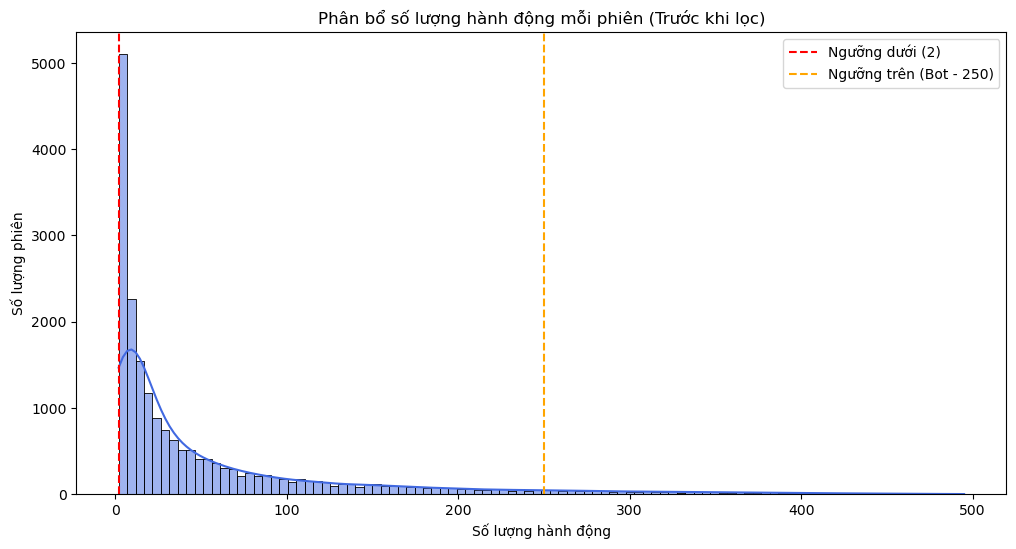

Thống kê mô tả số lượng hành động:
count    20000.000000
mean        56.382350
std         80.902717
min          2.000000
25%          6.000000
50%         21.000000
75%         69.000000
max        495.000000
Name: count, dtype: float64


In [ ]:
# 1. Tính số lượng hành động cho mỗi phiên
session_counts = df_flat.groupBy("session").count().orderBy(F.desc("count"))

# Chuyển sang Pandas để vẽ biểu đồ
pdf_counts = session_counts.toPandas()

# 2. Vẽ biểu đồ phân bổ ban đầu
plt.figure(figsize=(12, 6))
sns.histplot(pdf_counts['count'], bins=100, 
color='royalblue', kde=True)

# Vẽ các đường ranh giới rác đề xuất
plt.axvline(2, color='red', linestyle='--', label='Ngưỡng dưới (2)')
plt.axvline(250, color='orange', linestyle='--', label='Ngưỡng trên (Bot - 250)')

plt.title("Phân bổ số lượng hành động mỗi phiên (Trước khi lọc)")
plt.xlabel("Số lượng hành động")
plt.ylabel("Số lượng phiên")
plt.legend()
plt.show()

print("Thống kê mô tả số lượng hành động:")
print(pdf_counts['count'].describe())

In [19]:
from pyspark.sql import functions as F

# 1. Tính toán thống kê theo từng session
session_stats = df_flat.groupBy("session").agg(
    F.count("aid").alias("action_count"),
    F.min("ts").alias("start_ts"),
    F.max("ts").alias("end_ts")
)

# 2. Tính thời gian sống (giây) và cường độ (actions/giây)
# Lưu ý: Thêm 1 giây vào duration để tránh lỗi chia cho 0
session_stats = session_stats.withColumn(
    "duration_sec", (F.col("end_ts") - F.col("start_ts")) / 1000
).withColumn(
    "actions_per_second", F.col("action_count") / (F.col("duration_sec") + 0.1)
)

session_stats.cache()
session_stats.show(5)

+-------+------------+-------------+-------------+------------+--------------------+
|session|action_count|     start_ts|       end_ts|duration_sec|  actions_per_second|
+-------+------------+-------------+-------------+------------+--------------------+
|     26|          43|1659304800411|1660811509768| 1506709.357|2.853901248195324...|
|     29|          76|1659304800483|1661119746922| 1814946.439|4.187451165469288E-5|
|    474|         125|1659304807691|1661363586690| 2058778.999|6.071559598633753E-5|
|    964|           6|1659304815863|1659310576551|    5760.688|0.001041524180372...|
|   1677|           5|1659304830988|1661371654469| 2066823.481|2.419171160017842E-6|
+-------+------------+-------------+-------------+------------+--------------------+
only showing top 5 rows



In [21]:
# Thiết lập ngưỡng "Người thật"
MAX_APS = 2.0        # Không quá 2 hành động/giây
MIN_DURATION = 1.0   # Phiên phải dài ít nhất 1 giây nếu có nhiều hành động
MAX_DURATION = 86400 # Không quá 1 ngày

# Lọc danh sách session hợp lệ
valid_sessions_advanced = session_stats.filter(
    (F.col("actions_per_second") <= MAX_APS) & 
    (F.col("duration_sec") >= MIN_DURATION) &
    (F.col("duration_sec") <= MAX_DURATION) &
    (F.col("action_count") >= 2) &             # Vẫn giữ ngưỡng tối thiểu 2 action
    (F.col("action_count") <= 250)             # Vẫn giữ ngưỡng tối đa 250 action
).select("session")

# Tạo dataframe sạch cuối cùng
df_final_cleaned = df_flat.join(valid_sessions_advanced, on="session", how="inner")

print(f"Tổng số hành động ban đầu: {df_flat.count()}")
print(f"Số hành động sau khi lọc Bot & Cường độ: {df_final_cleaned.count()}")
print(f"Số lượng Session 'Người thật' còn lại: {valid_sessions_advanced.count()}")

df_final_cleaned.cache()

Tổng số hành động ban đầu: 1127647
Số hành động sau khi lọc Bot & Cường độ: 27516
Số lượng Session 'Người thật' còn lại: 3236


DataFrame[session: bigint, aid: bigint, ts: bigint, type: bigint, timestamp: timestamp, hour: int, day_of_week: int]